# `CompoundPoissonProcess`: totals that build up in lumps

A Poisson process counts events. Often the count is not what you care about.
An insurer does not want to know how many claims arrived today, it wants to
know how much was claimed. A **compound Poisson process** attaches a size to
each event and reports the running total instead of the count:

    X(t) = Y1 + Y2 + ... + Y_N(t)

where `N(t)` is the number of events by time `t` and `Y1, Y2, ...` are the
sizes, drawn independently from a distribution you choose. The events arrive
exactly as in `PoissonProcess`; the only new ingredient is one draw per event.

The same picture fits a lot of things: claims against an insurer, losses in a
portfolio, rainfall in storms, deposits and withdrawals in an account.

In [1]:
import numpy as np

from symbulate import *
from symbulate import distributions


def seed(value=42):
    """Make the draws below reproducible."""
    distributions.rng = np.random.default_rng(value)

## Claims arriving at an insurer

Three claims per day on average, each claim averaging 500. The rate goes in as
a number, exactly as in `PoissonProcess`; the claim size goes in as a whole
distribution.

Each draw of the process is a function of continuous time, so you can ask it
for the total claimed at any moment.

In [2]:
claims = CompoundPoissonProcess(rate=3, jump_dist=Exponential(rate=1 / 500))

seed()
path = claims.draw()
[round(float(path(t)), 2) for t in [0, 1, 2, 5, 10]]

[0.0, 1168.09, 2034.32, 6613.75, 11528.52]

The total starts at 0 and holds steady between claims, so a sample path is a
staircase: flat stretches while nothing happens, a vertical step whenever a
claim arrives. Unlike a count, the steps are not all the same height -- a big
claim makes a big step.

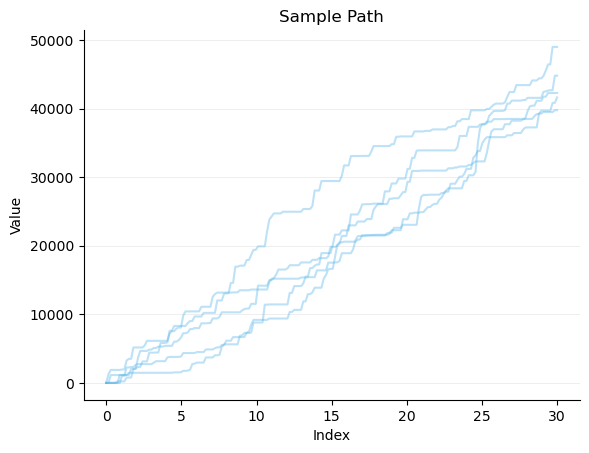

In [3]:
seed()
claims.sim(5).plot(tmin=0, tmax=30)

## What a path is made of

A path keeps the pieces it was built from, and they line up index by index:
the process waits `interarrival_times[n]`, then jumps by `jump_sizes[n]`. The
running total between events is `states[n]`, so `states[0]` is 0 -- the process
starts at 0 and nothing has jumped during the first wait.

In [4]:
print(" n   waited   claim arrived at   claim size   total after")
for n in range(6):
    print(
        f"{n:2}   {float(path.interarrival_times[n]):6.3f}"
        f"   {float(path.get_arrival_times()[n]):16.3f}"
        f"   {float(path.jump_sizes[n]):10.2f}"
        f"   {float(path.states[n + 1]):11.2f}"
    )

 n   waited   claim arrived at   claim size   total after
 0    0.801              0.801      1168.09       1168.09
 1    0.795              1.596       139.90       1307.99
 2    0.029              1.625       726.33       2034.32
 3    0.470              2.095      1562.15       3596.47
 4    0.026              2.122       523.28       4119.75
 5    0.023              2.145       544.51       4664.26


`states()`, `interarrival_times()`, and `arrival_times()` also work on a
compound path as plain functions, the same way they do on a Poisson process or
a continuous-time Markov chain path.

In [5]:
[round(float(s), 2) for s in states(path)[:4]]

[0.0, 1168.09, 1307.99, 2034.32]

## Checking it against the theory

Two closed forms are worth knowing, because they are the ones to check a
simulation against.

The **mean** is the average number of claims times the average size of one:

    E[X(t)] = rate * t * E[Y]

The **variance** is *not* the number of claims times the variance of a claim.
Both the number of claims and their sizes vary, and what combines the two is
the second moment:

    Var[X(t)] = rate * t * E[Y**2]

For `Exponential(rate=1/500)` claims, `E[Y] = 500` and `E[Y**2] = 2 * 500**2`.

In [6]:
mean_jump = 500
second_moment = 2 * 500**2
rate, t = 3, 30

seed()
total = claims(30).sim(10000)

print(f"simulated mean     = {total.mean():12.1f}")
print(f"rate * t * E[Y]    = {rate * t * mean_jump:12.1f}\n")
print(f"simulated variance = {total.var():12.1f}")
print(f"rate * t * E[Y^2]  = {rate * t * second_moment:12.1f}")
print(f"the tempting wrong answer, (rate * t) * Var(Y) = {rate * t * 500**2:12.1f}")

simulated mean     =      44970.1
rate * t * E[Y]    =      45000.0

simulated variance =   45646456.5
rate * t * E[Y^2]  =   45000000.0
the tempting wrong answer, (rate * t) * Var(Y) =   22500000.0


The wrong formula is off by a factor of two here, and it would be off by more
for a more variable claim size. It ignores the randomness in the *number* of
claims: even if every claim were exactly 500, the total would still vary,
because the count does.

The distribution of the total is right-skewed -- a day with a couple of large
claims pulls the upper tail out much further than a quiet day pulls the lower
one.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


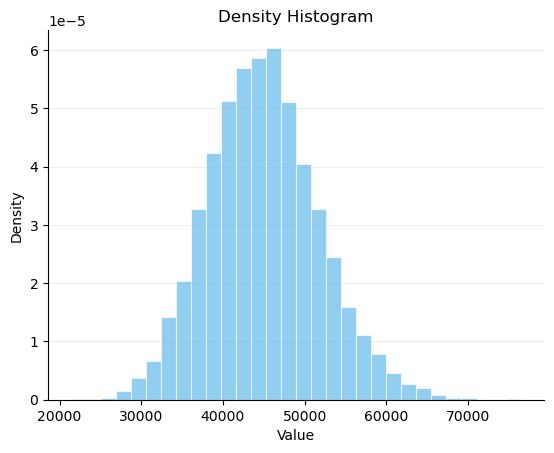

In [7]:
total.plot()

## The Poisson count is the special case

If every claim is exactly 1, the running total *is* the count, so the process
reduces to `PoissonProcess(rate=2)` and `X(5)` should be `Poisson(10)`. Two
plot calls in one cell overlay, so the simulated totals and the theoretical
distribution can be compared directly.

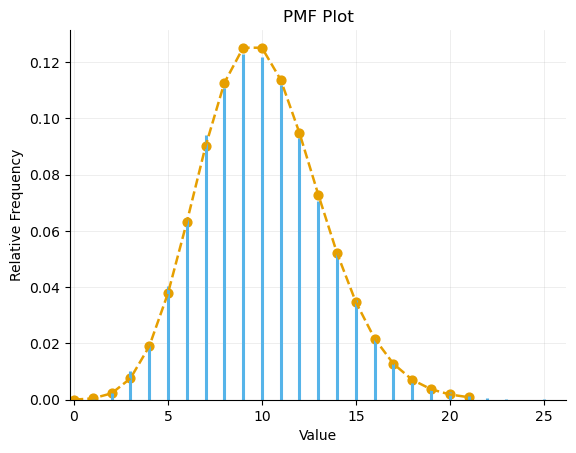

In [8]:
unit_jumps = CompoundPoissonProcess(rate=2, jump_dist=Uniform(a=1, b=1))

seed()
unit_jumps(5).sim(10000).plot()
Poisson(10).plot()

## Jumps are allowed to go down

A claim is positive, but a jump in general need not be. An account with
deposits and withdrawals arriving at random has jumps on both sides of zero,
and its total wanders up and down rather than climbing.

This is the one place where the compound process differs sharply from the
counting processes it is built on. `RenewalProcess` *refuses* a distribution
that can go negative, because a negative waiting time would make the count of
events go backwards -- a count that decreases is not a count. A total that
decreases is perfectly sensible, so nothing here is refused.

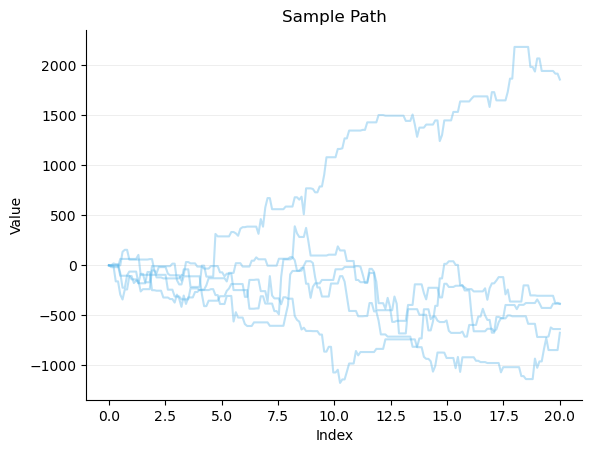

In [9]:
account = CompoundPoissonProcess(rate=5, jump_dist=Normal(mean=0, sd=100))

seed()
account.sim(5).plot(tmin=0, tmax=20)

In [10]:
try:
    RenewalProcess(Normal(mean=5, sd=1))
except ValueError as error:
    print(f"RenewalProcess(Normal(mean=5, sd=1)) refuses:\n  {error}\n")

seed()
fine = CompoundPoissonProcess(rate=2, jump_dist=Normal(mean=5, sd=1)).draw()
print(f"CompoundPoissonProcess with Normal jumps is fine: X(3) = {fine(3):.2f}")

RenewalProcess(Normal(mean=5, sd=1)) refuses:
  interarrival_dist must never produce a negative time, but Normal can produce values as small as -inf. The time between two events is a waiting time, so it cannot be negative -- a negative waiting time would make the count of events go backwards. Try a distribution that is never negative, such as Exponential(rate=1), Gamma(shape=2, rate=1), LogNormal(0, 1), or Uniform(a=0, b=2).

CompoundPoissonProcess with Normal jumps is fine: X(3) = 13.60


## A first look at ruin

The reason this process is a fixture of actuarial courses is the surplus
model. An insurer starts with reserves `u`, collects premiums at a steady rate
`c` per unit time, and pays claims as they arrive:

    U(t) = u + c * t - X(t)

Nothing new is needed to write that down -- `claims(30)` is an ordinary random
variable, so arithmetic on it works. Claims average `3 * 500 = 1,500` a day, so
premiums of 1,600 a day carry the roughly 7% safety loading the classical model
asks for. Starting from reserves of 10,000, the surplus after 30 days averages
about 13,000 -- and is still negative in about 4% of simulations.

In [11]:
u, premium_rate, horizon = 10000, 1600, 30

seed()
surplus = (u + premium_rate * horizon - claims(horizon)).sim(10000)

print(f"average surplus at day 30 = {surplus.mean():.1f}")
print(f"P(surplus at day 30 < 0)  = {surplus.count_lt(0) / 10000:.4f}")

average surplus at day 30 = 13029.9
P(surplus at day 30 < 0)  = 0.0360


Read that carefully: it is the chance of being under water **on day 30**, not
the chance of having gone under at any point during the 30 days. The second
one is the real ruin probability, and it is larger -- a path can dip below 0
mid-month and recover. Answering it needs a hitting time, which is its own
roadmap item; for now, a path can be checked at a grid of times by hand.

## The size distribution matters more than the mean

Two portfolios can agree on the average claim and disagree completely about
the bad days. `Pareto(shape=1.5, scale=500/3)` has a mean of 500, exactly like
the exponential claims above -- but it is heavy-tailed, so `E[Y**2]` is
infinite and the variance formula above has nothing to report.

In [12]:
heavy_claims = Pareto(shape=1.5, scale=500 / 3)
print(f"mean claim = {heavy_claims.mean():.1f},  variance = {heavy_claims.var()}")

mean claim = 500.0,  variance = inf


In [13]:
heavy = CompoundPoissonProcess(rate=3, jump_dist=heavy_claims)

seed()
light_total = claims(30).sim(10000)
seed()
heavy_total = heavy(30).sim(10000)

print(f"{'claim size':14}{'mean':>10}{'median':>10}{'99th pct':>12}{'worst seen':>14}")
for label, result in [("Exponential", light_total), ("Pareto", heavy_total)]:
    print(
        f"{label:14}{result.mean():10.0f}{result.median():10.0f}"
        f"{result.quantile(0.99):12.0f}{max(result):14.0f}"
    )

claim size          mean    median    99th pct    worst seen
Exponential        44970     44712       62136         76542
Pareto             45579     40398      124577       4040646


Same average total, and the heavy-tailed portfolio is actually *cheaper* in a
median month. But its worst month in 10,000 simulations is nearly a hundred
times the average, against less than twice the average for the exponential
claims. This is why the choice of severity distribution, not just its mean, is
the substance of an aggregate loss model.

## What the process refuses

Two arguments, two checks. `rate` must be a positive number -- it is the rate
of the underlying Poisson process, so the same rule `PoissonProcess` has
applies. `jump_dist` must be a Symbulate distribution of single numbers: one
size per event, not a vector, and not a bare number.

In [14]:
bad_arguments = [
    ("a rate of 0", 0, Exponential(rate=1)),
    ("a negative rate", -2, Exponential(rate=1)),
    ("a rate that is not a number", "fast", Exponential(rate=1)),
    ("a jump size given as a number", 2, 500),
    ("no jump distribution", 2, None),
    ("the class, not an instance", 2, Exponential),
    ("a multivariate jump", 2, BivariateNormal(mean1=1, mean2=1)),
]

for description, rate, jump_dist in bad_arguments:
    try:
        CompoundPoissonProcess(rate=rate, jump_dist=jump_dist)
    except (TypeError, ValueError) as error:
        print(f"{description}:\n  {error}\n")

a rate of 0:
  rate must be positive, got 0. A rate of 0 would mean no events ever occur, so the total would stay at 0 forever. Try a rate above 0 -- for example, rate=2 for two events per unit time on average.

a negative rate:
  rate must be positive, got -2. The rate is how frequently events happen, so it cannot go below 0. If what you wanted is a total that can go down as well as up, that belongs in jump_dist instead -- for example, jump_dist=Normal(mean=0, sd=1).

a rate that is not a number:
  rate must be a positive number: the average number of events per unit time. You gave str. For example, rate=2 for two events per unit time on average.

a jump size given as a number:
  jump_dist must be a Symbulate distribution describing the size of the jump at each event, such as Exponential(rate=1), Gamma(shape=2, rate=1), or Normal(mean=0, sd=1). You gave int. (If every jump is exactly 500, write that as a distribution too: Uniform(a=500, b=500).)

no jump distribution:
  jump_dist must

## Where this lives

- `symbulate/renewal_process.py` -- `CompoundPoissonProcess`,
  `CompoundPoissonProcessProbabilitySpace`, and
  `CompoundPoissonProcessResult`, alongside the `RenewalProcess`
  interarrival-time machinery they reuse.
- `symbulate/tests/test_renewal_process.py` -- tests for the sample path and
  its states, the two moments above, the unit-jump reduction to a Poisson
  count, and the validation shown here.
- `MODEL-DECISIONS.md`, "Decision: Compound Poisson Process" -- why it lives
  with the renewal process rather than with the Poisson family, and why
  `jump_dist` is deliberately not checked for sign.

**What this unblocks.** The Cramer-Lundberg surplus process is the ruin cell
above with a name; Sparre Andersen is the same construction with the
exponential waiting times replaced by any renewal waiting times; the aggregate
loss process is this with actuarial severity distributions; Merton
jump-diffusion is this added to geometric Brownian motion; and the shot-noise
process replaces the scalar jump with an impulse response. Each is a short
step from here.